In [1]:
%matplotlib inline
from matplotlib.pylab import plt

import pandas as pd
import numpy as np
import statsmodels

In [2]:
import statsmodels
print(statsmodels.__version__)
print(np.__version__)
print(pd.__version__)

0.14.6
2.0.2
2.2.2


# Let's start with some informal exploration

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving AirPassengers.csv to AirPassengers.csv
User uploaded file "AirPassengers.csv" with length 1746 bytes


In [4]:
air_passengers = pd.read_csv("AirPassengers.csv", header = 0, parse_dates = [0], names = ['Month', 'Passengers'], index_col = 0)

In [5]:
air_passengers.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


### Is this the behavior I want?

In [6]:
air_passengers['1949-01-05':'1949-02-17']

,Passengers
Month,
1949-02-01,118


In [7]:
# How do we get the desired behavior?

In [19]:
air_passengers['1949-01-05':'1949-02-17']

,Passengers
Month,
1949-02-01,118


### Think about what your data means. Pandas can't do the thinking for you

<Axes: xlabel='Month'>

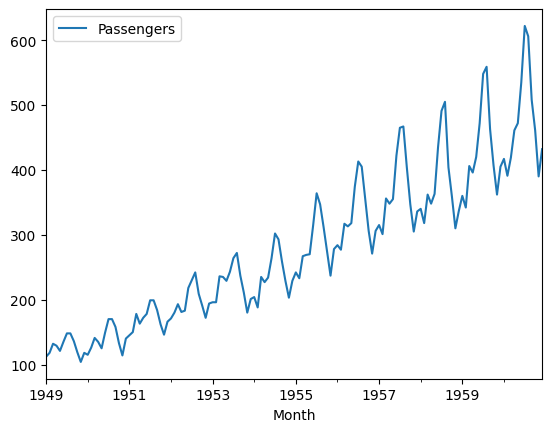

In [9]:
air_passengers.plot()

In [16]:
air_short = air_passengers.to_period()

<Axes: xlabel='Month'>

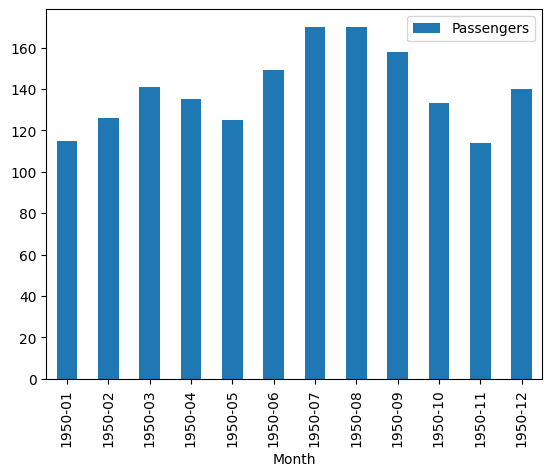

In [17]:
air_short['1950':'1950'].plot(kind = 'bar')

<Axes: xlabel='Month'>

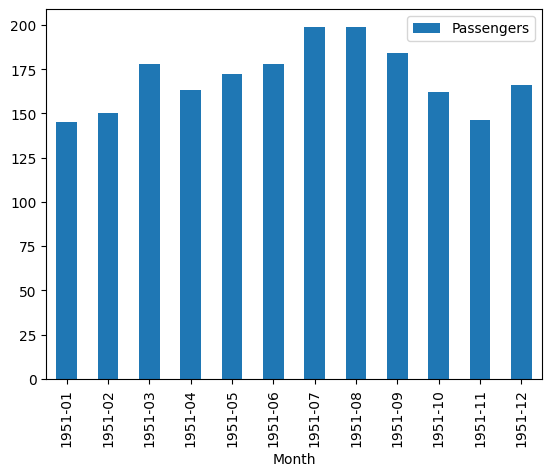

In [18]:
air_short['1951':'1951'].plot(kind = 'bar')

# Getting a little more formal
### first thing we look at for a time series when we want to use common analysis techniques:
### is it stationary: mean, variance, autocovariance do not depend on time

<Axes: xlabel='Month'>

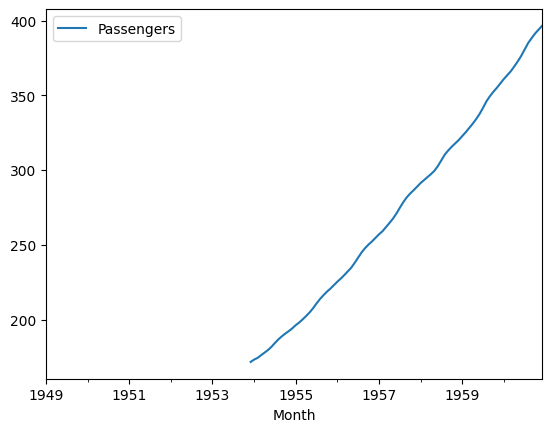

In [20]:
# first test, informally, plot the moving average
# note the ROLLING function
air_passengers.rolling(window = 60).mean().plot()

In [21]:
# How can we see whether the variance changes over time?

In [32]:
# Can you plot the autocorrelation?
from statsmodels.tsa.stattools import acf
import statsmodels.api as sm
import statsmodels.tsa.api as smt
from statsmodels.tsa.stattools import adfuller

In [26]:
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    if not isinstance(y, pd.Series):
        y = pd.Series(y)

    with plt.style.context(style):
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))

        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

In [27]:
# What is the autocorrelation and how can we visualize it?

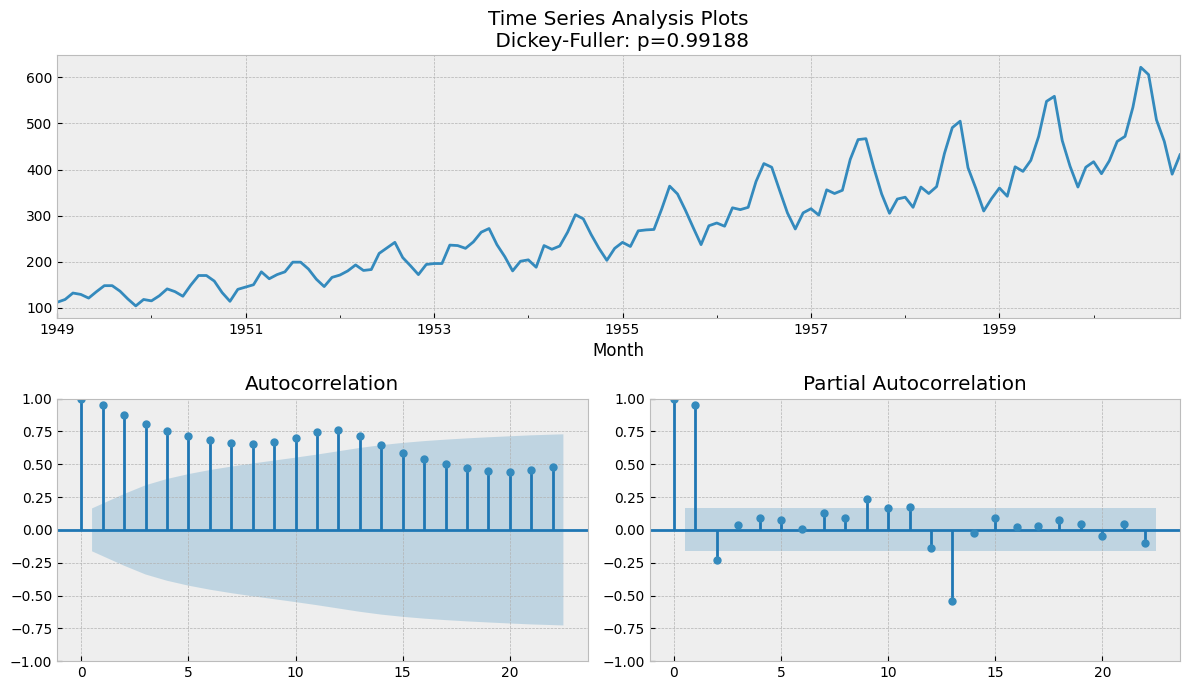

In [28]:
tsplot(air_passengers['Passengers'])

### How can I see whether the autocorrelation is changing over time?

In [33]:
# What would we do differently from above?
def test_stationarity(timeseries):
    #Determing rolling statistics
    MA = timeseries.rolling(window=12).mean()
    MSTD = timeseries.rolling(window=12).std()

    #Plot rolling statistics:
    plt.figure(figsize=(15,5))
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(MA, color='red', label='Rolling Mean')
    std = plt.plot(MSTD, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

    #Perform Dickey-Fuller test:
    print('Results of Dickey-Fuller Test:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

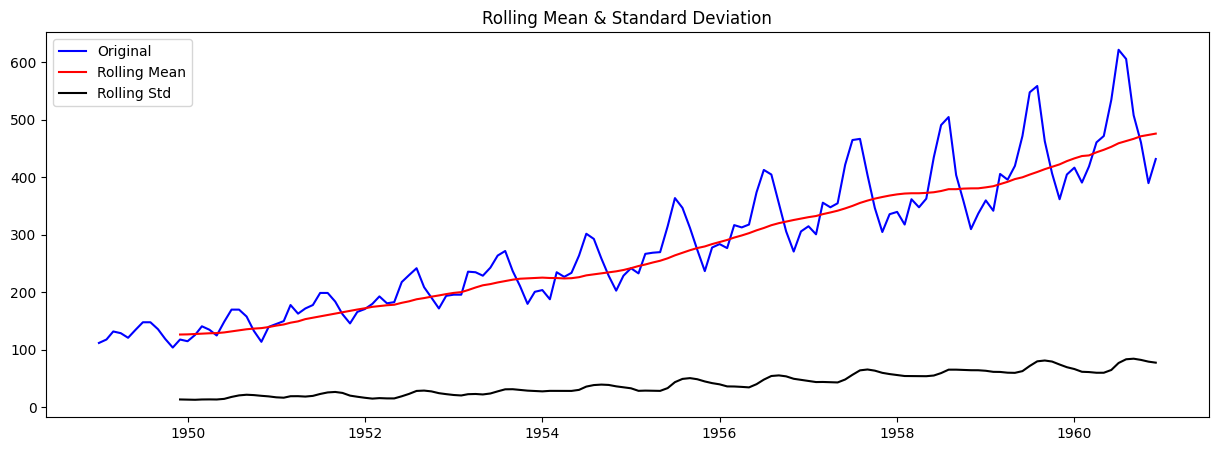

Results of Dickey-Fuller Test:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [34]:
test_stationarity(air_passengers['Passengers'])

### Always have to make judgment calls

<Axes: xlabel='Month'>

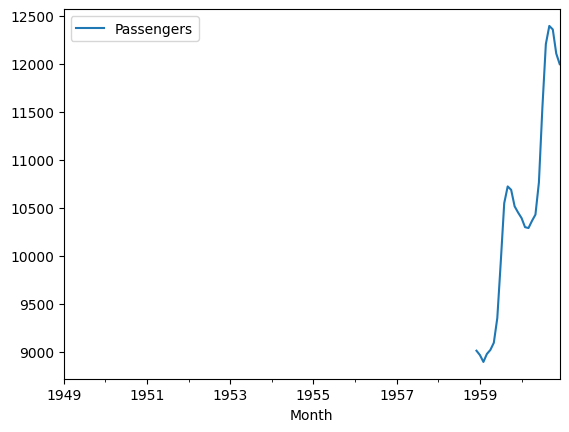

In [35]:
# How should you size your window?
air_passengers.rolling(window = 120).var().plot()

# And now let's make it formal

In [36]:
# next more formally apply the Augmented Dickey-Fuller test
from statsmodels.tsa.stattools import adfuller
adfuller(air_passengers.Passengers, autolag = 'AIC', regression = 'ct')

(np.float64(-2.100781813844672),
 np.float64(0.5456589343124537),
 13,
 130,
 {'1%': np.float64(-4.030152423759672),
  '5%': np.float64(-3.444817634956759),
  '10%': np.float64(-3.1471816659080565)},
 np.float64(993.2814778200581))

### What do these numbers mean? Let's take a look at statsmodels documentation

In [ ]:
# Can we write a function to output these #s sensibly?
# Check out statsmodels.sourceforge.net/devel/generated/statsmodels.tsa.stattools.adfuller.html

# Where do we go from here?

In [ ]:
# Are we stuck not doing any analysis now that our time series is not stationary? Hint: no.
# How can we make it stationary?
# Why is it non-stationary (2 reasons)

In order to make a non stationary dataset stationary, differencing must be used. the reason the dataset is non stationaary is because the dataset illustrates an upward trend towards taking flights as time goes on. another reaosn why its non stationary is that the adfuller test provided a p-value 0f 0.99 which is far from the required p-values of 0.05 for a dataset to be considered stationary.

<Axes: xlabel='Month'>

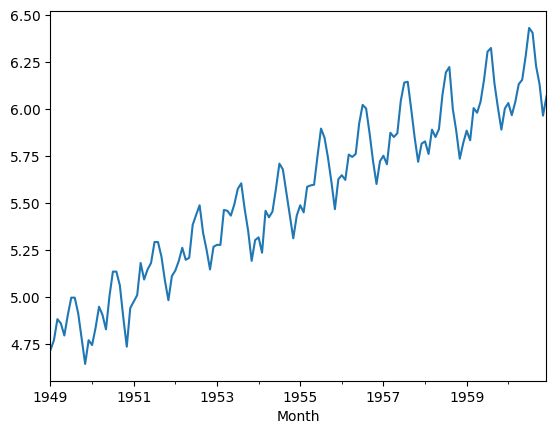

In [37]:
# One method to get rid of time varying variance is to do a power or log transformation that punishes larger values
# more than smaller values
log_passengers = air_passengers.Passengers.apply(lambda x: np.log(x))
log_passengers.plot()

<Axes: xlabel='Month'>

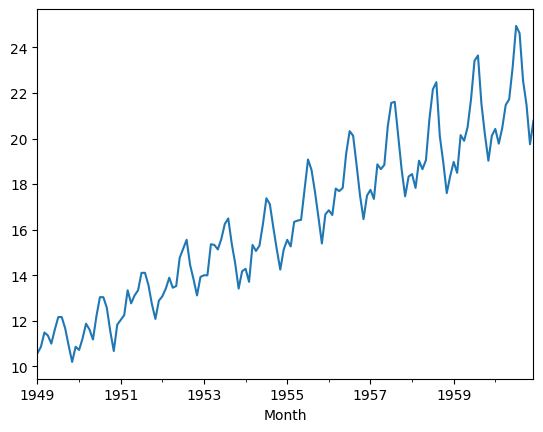

In [38]:
# Let's see what that looks like as a power transformation
rt_passengers = air_passengers.Passengers.apply(lambda x: x**.5)
rt_passengers.plot()

<Axes: xlabel='Month'>

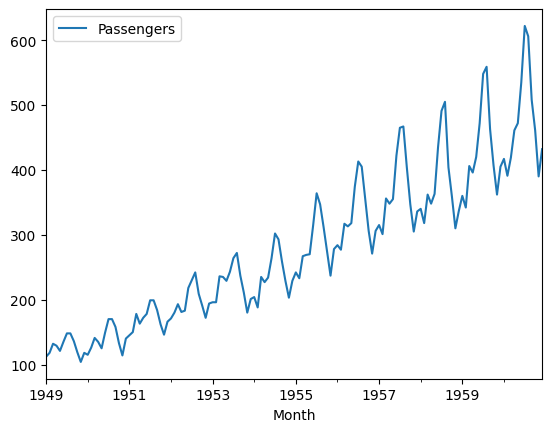

In [39]:
# This reduces the variance in variance as opposed to the original trend
air_passengers.plot()

<Axes: xlabel='Month'>

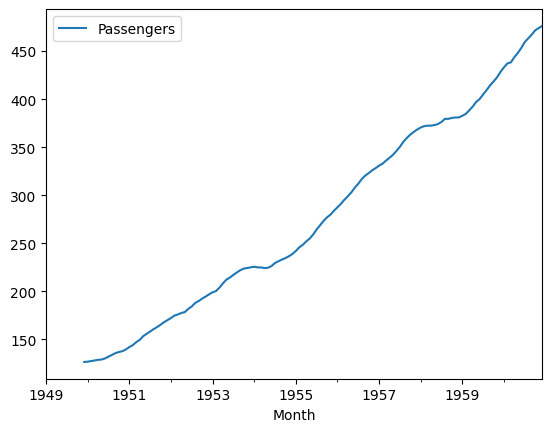

In [40]:
# However there is still a trend we need to remove
# Let's calculate a rolling mean
# Experiment with window size
air_passengers.rolling(window = 12).mean().plot()

<Axes: xlabel='Month'>

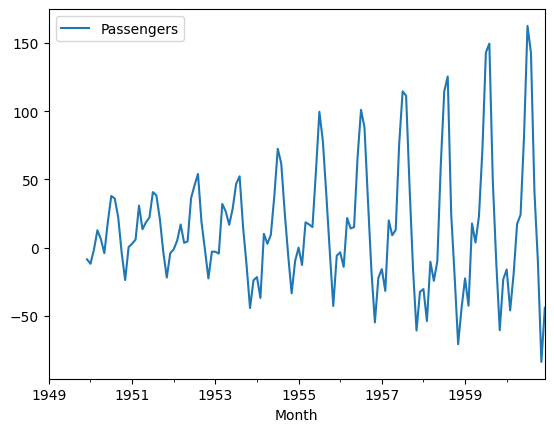

In [41]:
# What if we subtract this rolling mean from the original series?
rolling_mean = air_passengers.rolling(window = 12).mean()
passengers_detrended = air_passengers - rolling_mean
passengers_detrended.plot()

<Axes: xlabel='Month'>

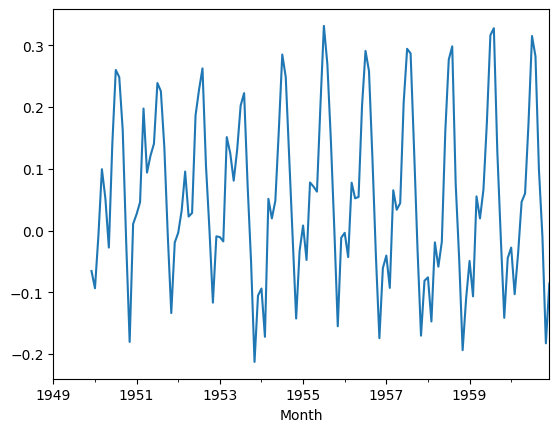

In [53]:
# Exercise: try detrending after taking the log. How does that look?
log_rolling_mean = log_passengers.rolling(window = 12).mean()
log_detrended = log_passengers - log_rolling_mean
log_detrended.plot()

<Axes: xlabel='Month'>

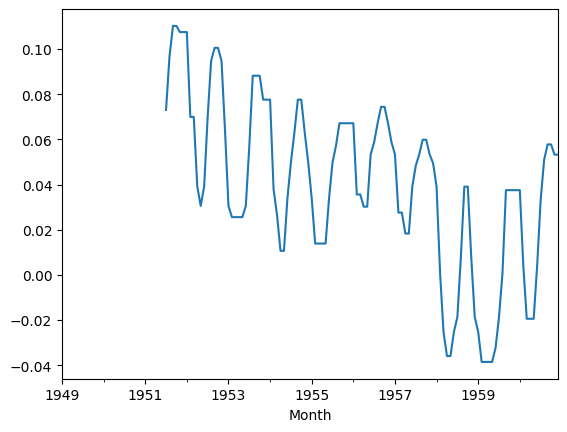

In [54]:
log_detrended.rolling(20).median().plot()

/tmp/ipython-input-1272320432.py:4: RuntimeWarning: invalid value encountered in log
  log_detrended2 = passengers_detrended.Passengers.apply(lambda x: np.log(x))


<Axes: xlabel='Month'>

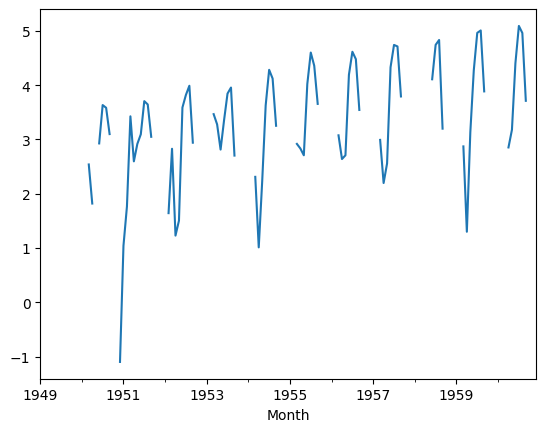

In [55]:
# Exercise: try detrending before taking the log. How does that look?
rolling_mean = air_passengers.rolling(window = 12).mean()
passengers_detrended = air_passengers - rolling_mean
log_detrended2 = passengers_detrended.Passengers.apply(lambda x: np.log(x))
log_detrended2.plot()

### Why didn't that work?

<Axes: xlabel='Month'>

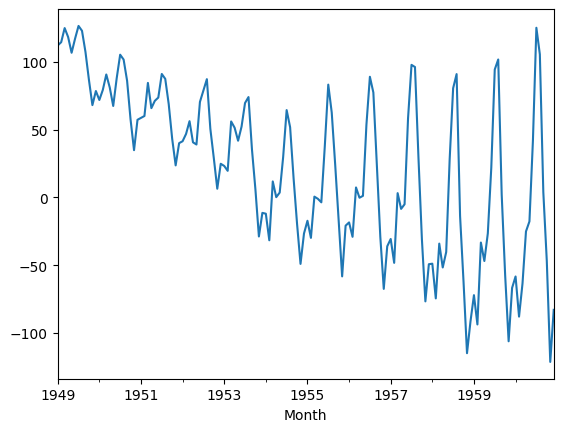

In [51]:
# Now let's use a regression rather than a rolling mean to detrend
from statsmodels.regression.linear_model import OLS
model = OLS(air_passengers.Passengers.values, list(range(len(air_passengers.values))))
result = model.fit()
result.params
fit = pd.Series(result.predict(list(range(len(air_passengers.values)))), index = air_passengers.index)

passengers_detrended = air_passengers.Passengers - fit
passengers_detrended.plot()

<Axes: xlabel='Month'>

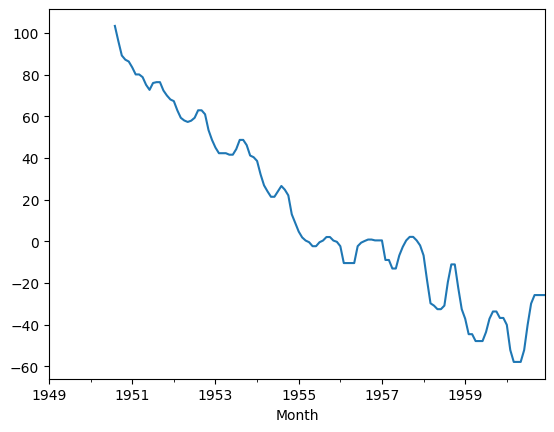

In [52]:
passengers_detrended.rolling(20).median().plot()

### What worked better, the rolling average or the regression? Why?

# Seasonality

### Differencing

<Axes: xlabel='Month'>

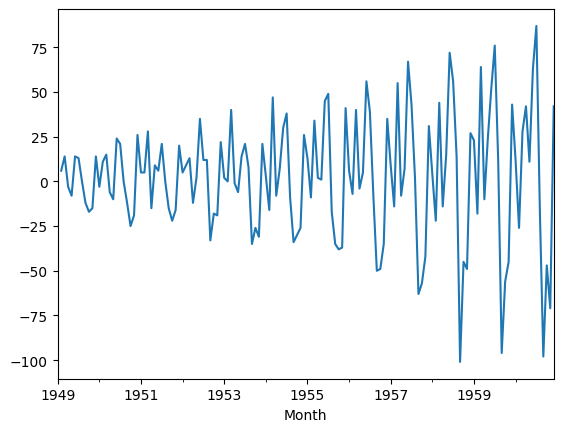

In [57]:
(air_passengers.Passengers - air_passengers.Passengers.shift()).plot()

<Axes: xlabel='Month'>

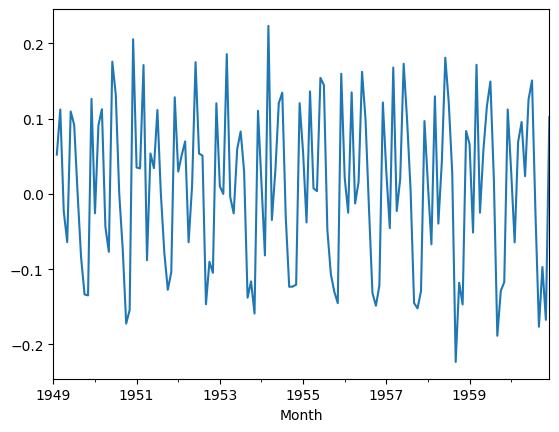

In [58]:
# One common technique is differencing, let's start with log_passengers
log_passengers_diff = log_passengers - log_passengers.shift()
log_passengers_diff.plot()

In [59]:
# Let's again test for stationarity with a gut level check.
# And let's write a function to do it since this seems like something we'll have to do a lot

In [63]:
log_passengers = log_passengers.to_timestamp()

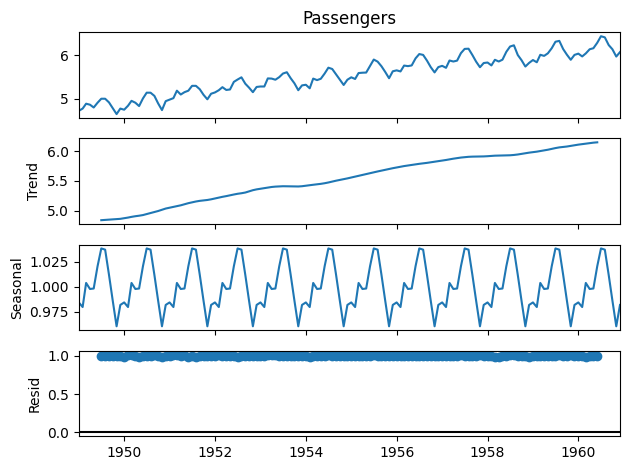

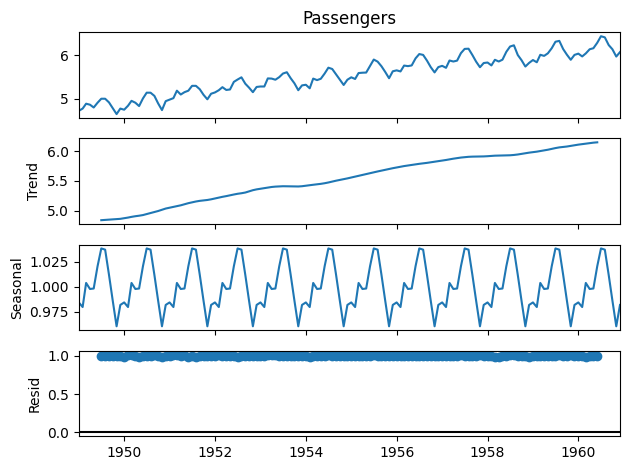

In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose

log_passengers.interpolate(inplace = True)
decomposition = seasonal_decompose(log_passengers, model = 'multiplicative')
decomposition.plot()

### Seasonal or multiplicative time series?

In [65]:
# When to use which?

In [66]:
decomposition = seasonal_decompose(log_passengers, model = 'multiplicative')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

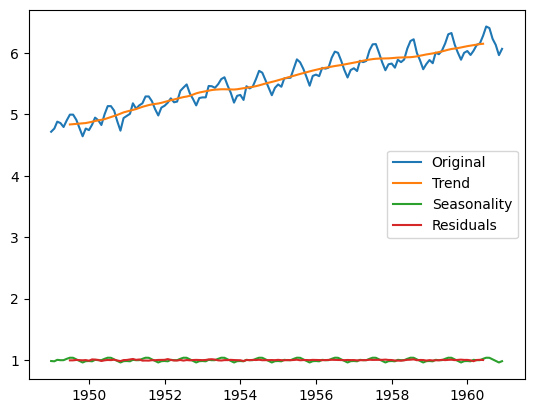

In [67]:
plt.plot(log_passengers, label='Original')
plt.plot(trend, label='Trend')
plt.plot(seasonal,label='Seasonality')
plt.plot(residual, label='Residuals')
plt.legend(loc = 'best')

# Let's walk through seasonal_decompose

In [69]:
# The seasonal_decompose function is already imported and available from statsmodels.tsa.seasonal
# The content of this cell is a redundant re-definition and is causing an ImportError.
# Removing the redundant definition.

ImportError: cannot import name 'range' from 'statsmodels.compat.python' (/usr/local/lib/python3.12/dist-packages/statsmodels/compat/python.py)

In [71]:
x = log_passengers
# _pandas_wrapper, pfreq = _maybe_get_pandas_wrapper_freq(x)
model = "multiplicative"

In [72]:
x = np.asanyarray(x).squeeze()

In [73]:
nobs = len(x)

In [74]:
nobs

144

In [75]:
if not np.all(np.isfinite(x)):
    raise ValueError("This function does not handle missing values")
if model.startswith('m'):
    if np.any(x <= 0):
        raise ValueError("Multiplicative seasonality is not appropriate "
                             "for zero and negative values")

In [77]:
# freq = None
# if freq is None:
#     if pfreq is not None:
#         pfreq = freq_to_period(pfreq)
#         freq = pfreq
#     else:
#         raise ValueError("You must specify a freq or x must be a "
#                          "pandas object with a timeseries index with"
#                          "a freq not set to None")

In [78]:
pfreq

NameError: name 'pfreq' is not defined

In [90]:
freq

In [92]:
# filt = None
# two_sided = True
# if filt is None:
#     if freq % 2 == 0:  # split weights at ends
#         filt = np.array([.5] + [1] * (freq - 1) + [.5]) / freq
#     else:
#         filt = np.repeat(1./freq, freq)

# nsides = int(two_sided) + 1
# trend = convolution_filter(x, filt, nsides)

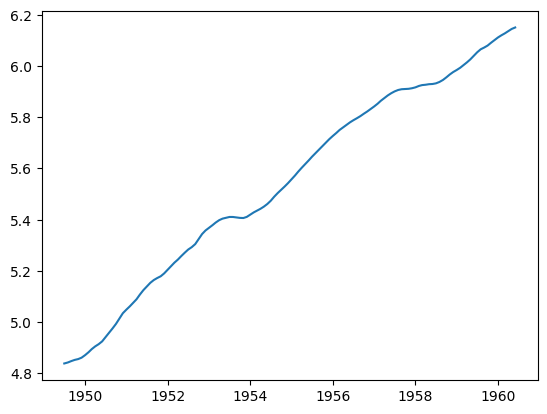

In [80]:
plt.plot(trend)

In [93]:
# plt.plot(filt)

In [82]:
if model.startswith('m'):
    detrended = x / trend
else:
    detrended = x - trend

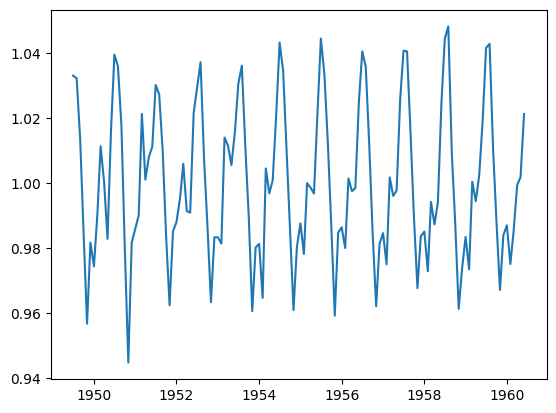

In [83]:
plt.plot(detrended)

In [84]:
def seasonal_mean(x, freq):
    """
    Return means for each period in x. freq is an int that gives the
    number of periods per cycle. E.g., 12 for monthly. NaNs are ignored
    in the mean.
    """
    return np.array([pd_nanmean(x[i::freq]) for i in range(freq)])

In [87]:
# period_averages = seasonal_mean(detrended, freq)

# if model.startswith('m'):
#     period_averages /= np.mean(period_averages)
# else:
#     period_averages -= np.mean(period_averages)

# seasonal = np.tile(period_averages, nobs // freq + 1)[:nobs]

# if model.startswith('m'):
#     resid = x / seasonal / trend
# else:
#     resid = detrended - seasonal

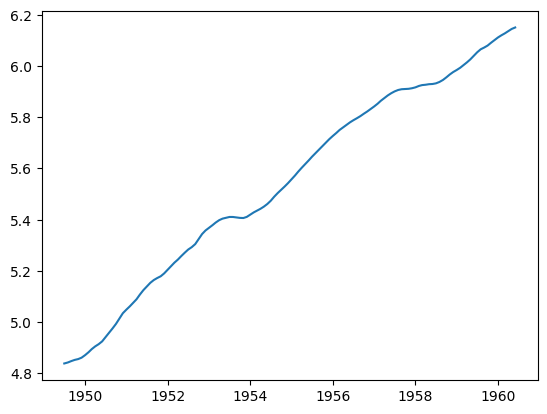

In [88]:
plt.plot(trend)